In [1]:
!pip install torch torchvision scikit-learn matplotlib seaborn pillow

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, Dataset
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid

In [3]:
# Set random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
# Update this path based on your system
data_dir = "/content/chest_xray"   # Change this if needed

train_dir = os.path.join(data_dir, "train")
val_dir   = os.path.join(data_dir, "val")
test_dir  = os.path.join(data_dir, "test")

synthetic_dir = "/content/synthetic_xray"
os.makedirs(synthetic_dir, exist_ok=True)

synthetic_normal_dir = os.path.join(synthetic_dir, "NORMAL")
synthetic_pneumonia_dir = os.path.join(synthetic_dir, "PNEUMONIA")

os.makedirs(synthetic_normal_dir, exist_ok=True)
os.makedirs(synthetic_pneumonia_dir, exist_ok=True)

In [6]:
# Image size for GAN and classifier
image_size = 64
batch_size = 64

import zipfile

# Unzip the dataset if it hasn't been already
zip_path = '/content/chest_xray.zip'
if not os.path.exists(data_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content')
    # The extracted folder might be named 'chest_xray' or 'chest_xray_new'
    # Let's assume it extracts directly into /content/chest_xray as per data_dir setup
    print(f"Unzipped {zip_path} to /content/")

# Transform for GAN and classifier
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # ensure grayscale
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # pixel range [-1, 1]
])

# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
val_dataset   = datasets.ImageFolder(root=val_dir, transform=transform)
test_dataset  = datasets.ImageFolder(root=test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Unzipped /content/chest_xray.zip to /content/
Classes: ['NORMAL', 'PNEUMONIA']
Train size: 5216
Validation size: 16
Test size: 624


In [7]:
# Count class distribution
class_counts = {class_name: 0 for class_name in train_dataset.classes}

for _, label in train_dataset.samples:
    class_name = train_dataset.classes[label]
    class_counts[class_name] += 1

print("Training class distribution:")
for k, v in class_counts.items():
    print(f"{k}: {v}")

Training class distribution:
NORMAL: 1341
PNEUMONIA: 3875


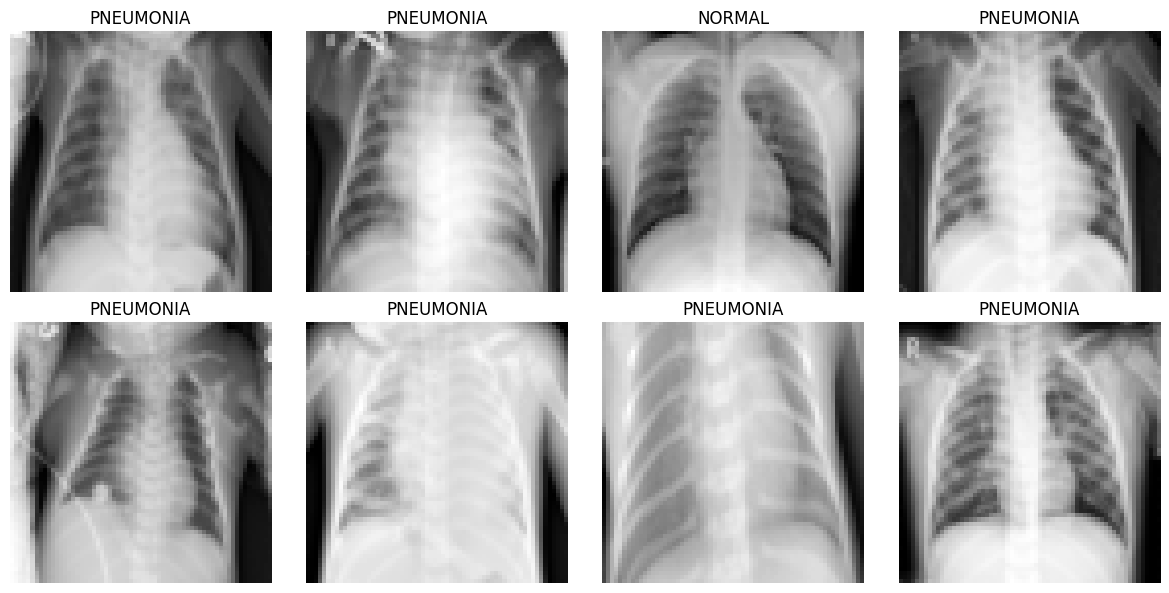

In [8]:
# Show sample training images
def imshow_tensor(img_tensor, title=None):
    img = img_tensor.clone().detach().cpu()
    img = img * 0.5 + 0.5  # unnormalize to [0,1]
    img = img.squeeze(0)
    plt.imshow(img, cmap='gray')
    if title:
        plt.title(title)
    plt.axis('off')

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    imshow_tensor(images[i], title=train_dataset.classes[labels[i].item()])
plt.tight_layout()
plt.show()

In [9]:
# Generator network
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [10]:
# Discriminator network
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1)

In [11]:
# Initialize weights for stable GAN training
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [12]:
# GAN hyperparameters
latent_dim = 100
lr_gan = 0.0002
num_epochs_gan = 50
beta1 = 0.5

In [13]:
# Create models
generator = Generator(latent_dim=latent_dim).to(device)
discriminator = Discriminator().to(device)

generator.apply(weights_init)
discriminator.apply(weights_init)

# Loss and optimizers
criterion = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=lr_gan, betas=(beta1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_gan, betas=(beta1, 0.999))

print(generator)
print(discriminator)

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)

Epoch [1/50] | Loss D: 0.2003 | Loss G: 3.3707
Epoch [2/50] | Loss D: 1.6074 | Loss G: 5.5697
Epoch [3/50] | Loss D: 0.7178 | Loss G: 2.9689
Epoch [4/50] | Loss D: 0.4865 | Loss G: 3.6212
Epoch [5/50] | Loss D: 0.3668 | Loss G: 4.6891
Epoch [6/50] | Loss D: 0.3863 | Loss G: 3.9594
Epoch [7/50] | Loss D: 0.5151 | Loss G: 4.6694
Epoch [8/50] | Loss D: 0.8811 | Loss G: 7.9951
Epoch [9/50] | Loss D: 0.9498 | Loss G: 2.4791
Epoch [10/50] | Loss D: 0.3810 | Loss G: 4.9328


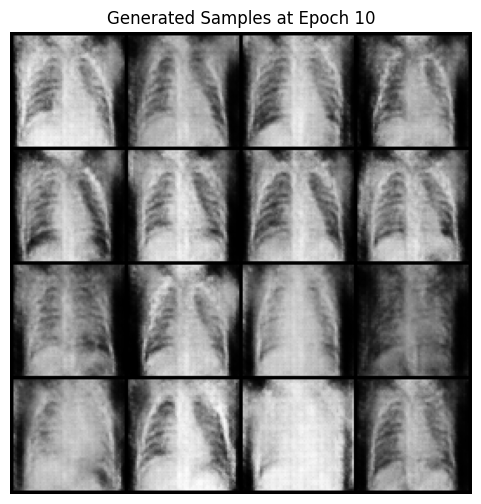

Epoch [11/50] | Loss D: 0.3311 | Loss G: 3.7163
Epoch [12/50] | Loss D: 0.4288 | Loss G: 4.9045
Epoch [13/50] | Loss D: 0.3343 | Loss G: 4.4269
Epoch [14/50] | Loss D: 0.5008 | Loss G: 6.8565
Epoch [15/50] | Loss D: 0.3301 | Loss G: 3.5710
Epoch [16/50] | Loss D: 0.2491 | Loss G: 3.3345
Epoch [17/50] | Loss D: 0.3924 | Loss G: 6.2735
Epoch [18/50] | Loss D: 0.6532 | Loss G: 8.2411
Epoch [19/50] | Loss D: 0.2490 | Loss G: 4.8971
Epoch [20/50] | Loss D: 0.4469 | Loss G: 5.7569


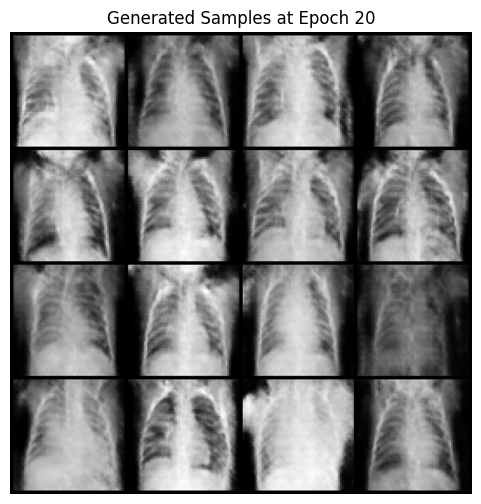

Epoch [21/50] | Loss D: 0.4482 | Loss G: 7.5501
Epoch [22/50] | Loss D: 0.3315 | Loss G: 4.1451
Epoch [23/50] | Loss D: 0.5861 | Loss G: 2.4357
Epoch [24/50] | Loss D: 0.4311 | Loss G: 8.3238
Epoch [25/50] | Loss D: 0.1488 | Loss G: 5.0930
Epoch [26/50] | Loss D: 0.2864 | Loss G: 3.7834
Epoch [27/50] | Loss D: 0.3965 | Loss G: 7.0316
Epoch [28/50] | Loss D: 0.2686 | Loss G: 3.5319
Epoch [29/50] | Loss D: 0.3302 | Loss G: 3.3663
Epoch [30/50] | Loss D: 0.3212 | Loss G: 6.5570


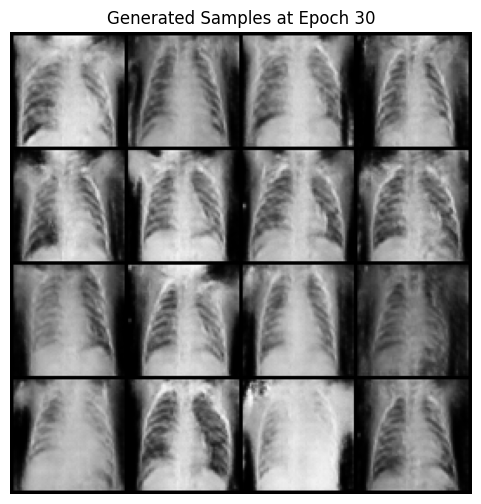

Epoch [31/50] | Loss D: 0.3423 | Loss G: 6.5639
Epoch [32/50] | Loss D: 0.1058 | Loss G: 6.0510
Epoch [33/50] | Loss D: 0.4167 | Loss G: 6.4973
Epoch [34/50] | Loss D: 0.1455 | Loss G: 5.4012
Epoch [35/50] | Loss D: 0.3374 | Loss G: 3.9865
Epoch [36/50] | Loss D: 1.2621 | Loss G: 3.1361
Epoch [37/50] | Loss D: 0.2276 | Loss G: 5.7052
Epoch [38/50] | Loss D: 0.2146 | Loss G: 6.9092
Epoch [39/50] | Loss D: 0.1935 | Loss G: 5.6691
Epoch [40/50] | Loss D: 0.0949 | Loss G: 5.4483


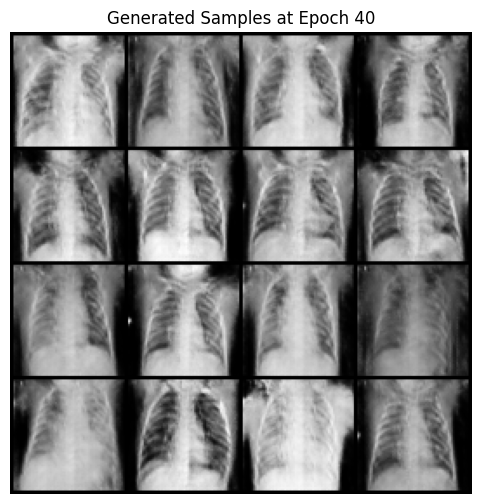

Epoch [41/50] | Loss D: 0.1651 | Loss G: 4.7208
Epoch [42/50] | Loss D: 0.2793 | Loss G: 3.6075
Epoch [43/50] | Loss D: 0.8859 | Loss G: 4.1425
Epoch [44/50] | Loss D: 0.1707 | Loss G: 3.6929
Epoch [45/50] | Loss D: 0.3936 | Loss G: 6.0480
Epoch [46/50] | Loss D: 0.1714 | Loss G: 5.1501
Epoch [47/50] | Loss D: 0.0790 | Loss G: 4.7877
Epoch [48/50] | Loss D: 0.1760 | Loss G: 6.6554
Epoch [49/50] | Loss D: 0.2032 | Loss G: 4.2963
Epoch [50/50] | Loss D: 0.2101 | Loss G: 5.2054


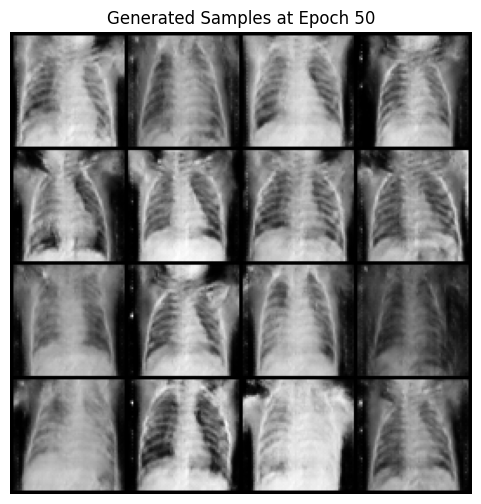

In [14]:
g_losses = []
d_losses = []

fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)

for epoch in range(num_epochs_gan):
    for i, (real_images, _) in enumerate(train_loader):
        real_images = real_images.to(device)
        batch_size_curr = real_images.size(0)

        real_labels = torch.ones(batch_size_curr, device=device)
        fake_labels = torch.zeros(batch_size_curr, device=device)

        # -------------------------
        # Train Discriminator
        # -------------------------
        optimizer_D.zero_grad()

        outputs_real = discriminator(real_images)
        loss_real = criterion(outputs_real, real_labels)

        noise = torch.randn(batch_size_curr, latent_dim, 1, 1, device=device)
        fake_images = generator(noise)

        outputs_fake = discriminator(fake_images.detach())
        loss_fake = criterion(outputs_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # -------------------------
        # Train Generator
        # -------------------------
        optimizer_G.zero_grad()

        outputs_fake_for_G = discriminator(fake_images)
        loss_G = criterion(outputs_fake_for_G, real_labels)  # want fake to be classified as real

        loss_G.backward()
        optimizer_G.step()

    g_losses.append(loss_G.item())
    d_losses.append(loss_D.item())

    print(f"Epoch [{epoch+1}/{num_epochs_gan}] | Loss D: {loss_D.item():.4f} | Loss G: {loss_G.item():.4f}")

    # Save sample generated images every 10 epochs
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            fake_samples = generator(fixed_noise).detach().cpu()
            grid = make_grid(fake_samples, nrow=4, normalize=True)
            plt.figure(figsize=(6, 6))
            plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
            plt.title(f"Generated Samples at Epoch {epoch+1}")
            plt.axis("off")
            plt.show()

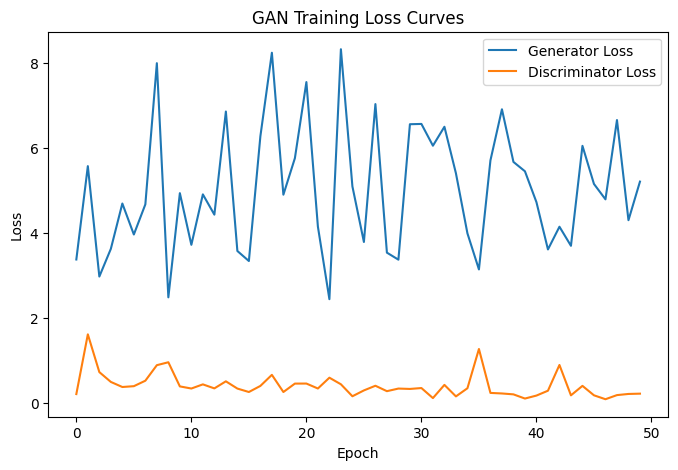

In [15]:
# Plot generator and discriminator loss curves
plt.figure(figsize=(8, 5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss Curves")
plt.legend()
plt.show()

In [16]:
# Function to save generated images
def generate_and_save_images(generator, save_dir, num_images=500, latent_dim=100):
    generator.eval()
    count = 0

    with torch.no_grad():
        while count < num_images:
            batch_noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
            fake_images = generator(batch_noise)

            for img in fake_images:
                if count >= num_images:
                    break
                save_path = os.path.join(save_dir, f"synthetic_{count}.png")
                save_image(img * 0.5 + 0.5, save_path)  # convert back to [0,1]
                count += 1

    print(f"{num_images} synthetic images saved to {save_dir}")

In [18]:
generate_and_save_images(generator, synthetic_pneumonia_dir, num_images=500, latent_dim=latent_dim)

500 synthetic images saved to /content/synthetic_xray/PNEUMONIA


1000 synthetic images saved to /content/synthetic_xray/NORMAL
Synthetic preview dataset size: 1500


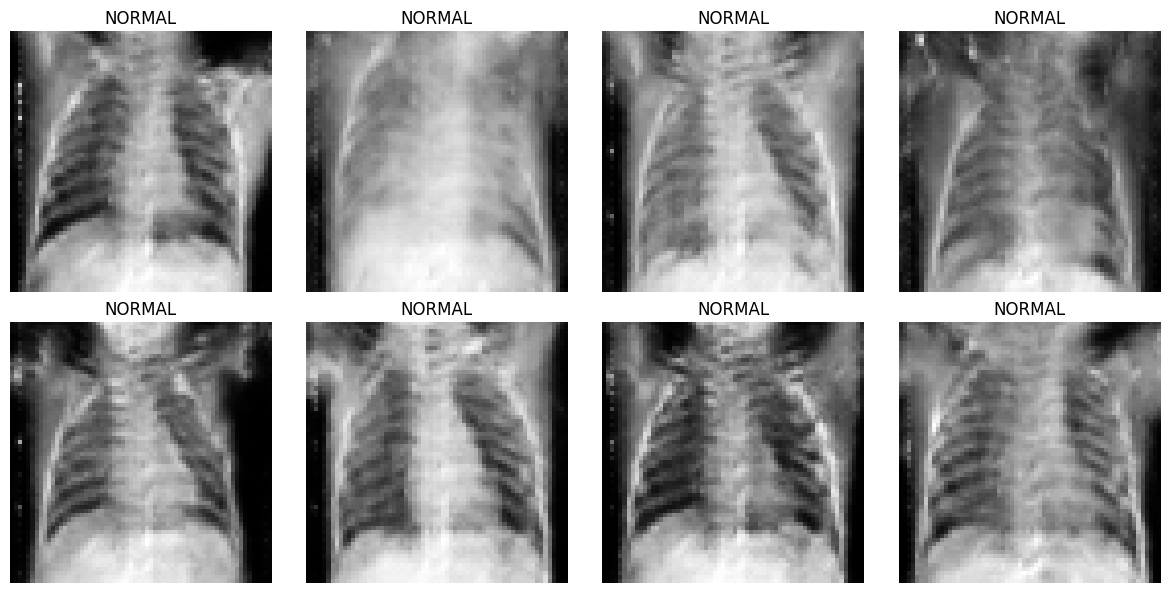

In [20]:
# Call the function to generate and save synthetic images
# We'll generate synthetic 'NORMAL' images
generate_and_save_images(generator, synthetic_normal_dir, num_images=1000, latent_dim=latent_dim)

# Display some saved synthetic images
synthetic_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

synthetic_dataset_preview = datasets.ImageFolder(root=synthetic_dir, transform=synthetic_transform)

print("Synthetic preview dataset size:", len(synthetic_dataset_preview))

plt.figure(figsize=(12, 6))
for i in range(min(8, len(synthetic_dataset_preview))):
    img, label = synthetic_dataset_preview[i]
    plt.subplot(2, 4, i+1)
    plt.imshow(img.squeeze(0), cmap='gray')
    plt.title(synthetic_dataset_preview.classes[label])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [21]:
# Simple CNN classifier for binary classification
class ChestXrayCNN(nn.Module):
    def __init__(self):
        super(ChestXrayCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)   # 2 classes: NORMAL and PNEUMONIA
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [22]:
def train_classifier(model, train_loader, val_loader, epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()

        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    return train_losses, val_losses

In [23]:
def evaluate_model(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='binary')
    rec = recall_score(y_true, y_pred, average='binary')
    f1 = f1_score(y_true, y_pred, average='binary')
    cm = confusion_matrix(y_true, y_pred)

    return acc, prec, rec, f1, cm, y_true, y_pred

In [24]:
# Baseline training on original dataset only
classifier_baseline = ChestXrayCNN().to(device)

baseline_train_losses, baseline_val_losses = train_classifier(
    classifier_baseline,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001
)

baseline_acc, baseline_prec, baseline_rec, baseline_f1, baseline_cm, y_true_base, y_pred_base = evaluate_model(
    classifier_baseline, test_loader
)

print("\nBaseline Results")
print("Accuracy :", baseline_acc)
print("Precision:", baseline_prec)
print("Recall   :", baseline_rec)
print("F1-score :", baseline_f1)
print("Confusion Matrix:\n", baseline_cm)

Epoch [1/10] | Train Loss: 0.2994 | Val Loss: 1.0187
Epoch [2/10] | Train Loss: 0.1478 | Val Loss: 0.2806
Epoch [3/10] | Train Loss: 0.1175 | Val Loss: 0.2123
Epoch [4/10] | Train Loss: 0.0957 | Val Loss: 0.3803
Epoch [5/10] | Train Loss: 0.0914 | Val Loss: 0.2701
Epoch [6/10] | Train Loss: 0.0755 | Val Loss: 1.4364
Epoch [7/10] | Train Loss: 0.0719 | Val Loss: 0.7612
Epoch [8/10] | Train Loss: 0.0688 | Val Loss: 0.7237
Epoch [9/10] | Train Loss: 0.0658 | Val Loss: 0.5619
Epoch [10/10] | Train Loss: 0.0556 | Val Loss: 0.2005

Baseline Results
Accuracy : 0.7980769230769231
Precision: 0.7598425196850394
Recall   : 0.9897435897435898
F1-score : 0.8596881959910914
Confusion Matrix:
 [[112 122]
 [  4 386]]


In [25]:
# Synthetic dataset transform
synthetic_transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

synthetic_dataset = datasets.ImageFolder(root=synthetic_dir, transform=synthetic_transform_train)

# Combine real + synthetic
augmented_train_dataset = ConcatDataset([train_dataset, synthetic_dataset])

augmented_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=batch_size,
    shuffle=True
)

print("Original train size:", len(train_dataset))
print("Synthetic size:", len(synthetic_dataset))
print("Augmented train size:", len(augmented_train_dataset))

Original train size: 5216
Synthetic size: 1500
Augmented train size: 6716


In [26]:
# Train classifier on augmented dataset
classifier_augmented = ChestXrayCNN().to(device)

aug_train_losses, aug_val_losses = train_classifier(
    classifier_augmented,
    augmented_train_loader,
    val_loader,
    epochs=10,
    lr=0.001
)

aug_acc, aug_prec, aug_rec, aug_f1, aug_cm, y_true_aug, y_pred_aug = evaluate_model(
    classifier_augmented, test_loader
)

print("\nAugmented Results")
print("Accuracy :", aug_acc)
print("Precision:", aug_prec)
print("Recall   :", aug_rec)
print("F1-score :", aug_f1)
print("Confusion Matrix:\n", aug_cm)

Epoch [1/10] | Train Loss: 0.5064 | Val Loss: 0.6044
Epoch [2/10] | Train Loss: 0.3688 | Val Loss: 0.4814
Epoch [3/10] | Train Loss: 0.2990 | Val Loss: 0.7094
Epoch [4/10] | Train Loss: 0.2701 | Val Loss: 0.5157
Epoch [5/10] | Train Loss: 0.2320 | Val Loss: 0.3950
Epoch [6/10] | Train Loss: 0.2141 | Val Loss: 0.4614
Epoch [7/10] | Train Loss: 0.2076 | Val Loss: 0.3029
Epoch [8/10] | Train Loss: 0.2001 | Val Loss: 0.5541
Epoch [9/10] | Train Loss: 0.1851 | Val Loss: 0.3011
Epoch [10/10] | Train Loss: 0.1784 | Val Loss: 0.7165

Augmented Results
Accuracy : 0.7435897435897436
Precision: 0.7106227106227107
Recall   : 0.9948717948717949
F1-score : 0.8290598290598291
Confusion Matrix:
 [[ 76 158]
 [  2 388]]


In [27]:
# Compare results in a table-like format
print("\nComparison of Baseline vs Augmented")
print(f"{'Metric':<12} {'Baseline':<12} {'Augmented':<12}")
print("-" * 36)
print(f"{'Accuracy':<12} {baseline_acc:<12.4f} {aug_acc:<12.4f}")
print(f"{'Precision':<12} {baseline_prec:<12.4f} {aug_prec:<12.4f}")
print(f"{'Recall':<12} {baseline_rec:<12.4f} {aug_rec:<12.4f}")
print(f"{'F1-score':<12} {baseline_f1:<12.4f} {aug_f1:<12.4f}")


Comparison of Baseline vs Augmented
Metric       Baseline     Augmented   
------------------------------------
Accuracy     0.7981       0.7436      
Precision    0.7598       0.7106      
Recall       0.9897       0.9949      
F1-score     0.8597       0.8291      


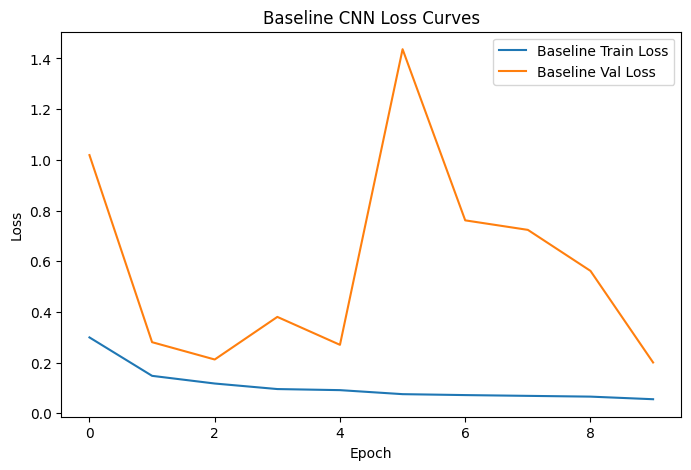

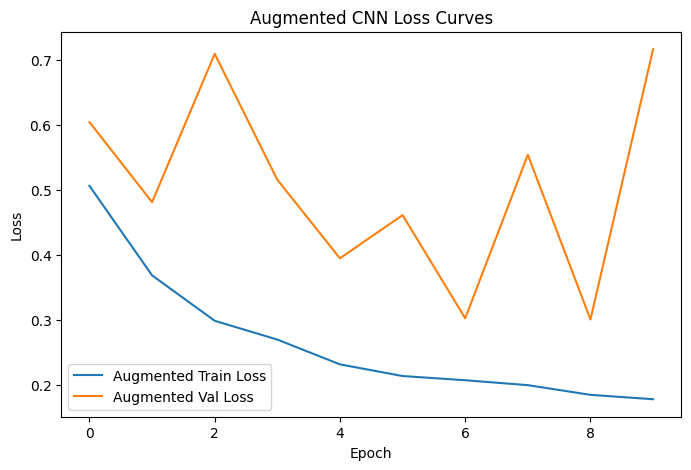

In [28]:
# Plot baseline and augmented classifier loss curves
plt.figure(figsize=(8, 5))
plt.plot(baseline_train_losses, label='Baseline Train Loss')
plt.plot(baseline_val_losses, label='Baseline Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Loss Curves")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(aug_train_losses, label='Augmented Train Loss')
plt.plot(aug_val_losses, label='Augmented Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Augmented CNN Loss Curves")
plt.legend()
plt.show()

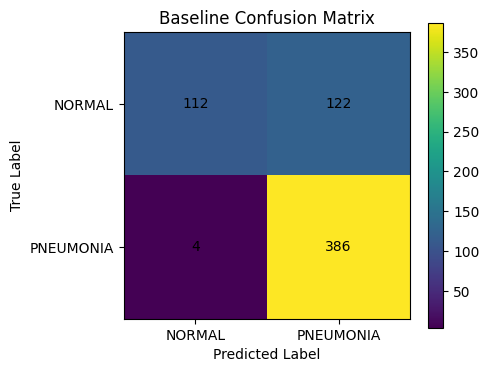

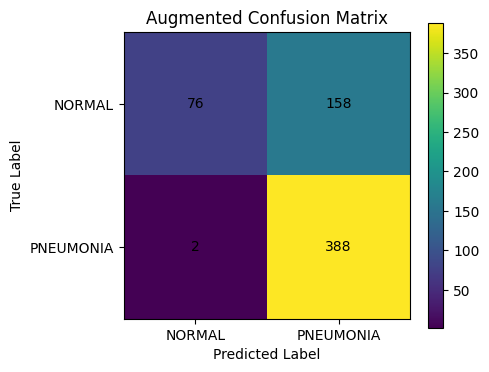

In [29]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['NORMAL', 'PNEUMONIA'])
    plt.yticks(tick_marks, ['NORMAL', 'PNEUMONIA'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(baseline_cm, "Baseline Confusion Matrix")
plot_confusion_matrix(aug_cm, "Augmented Confusion Matrix")

In [30]:
learning_rates = [0.0001, 0.0002, 0.0005]

In [31]:
batch_sizes = [32, 64, 128]

In [32]:
latent_dims = [50, 100, 150]

In [33]:
gan_epochs_list = [25, 50, 100]

In [34]:
# Example experiment loop for latent dimension
experiment_results = []

for z_dim in [50, 100, 150]:
    print(f"\nRunning experiment with latent dimension = {z_dim}")

    generator = Generator(latent_dim=z_dim).to(device)
    discriminator = Discriminator().to(device)

    generator.apply(weights_init)
    discriminator.apply(weights_init)

    criterion = nn.BCELoss()
    optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

    # You may reduce epochs for quick experiments
    temp_g_losses = []
    temp_d_losses = []

    for epoch in range(10):  # smaller for quick study
        for real_images, _ in train_loader:
            real_images = real_images.to(device)
            batch_size_curr = real_images.size(0)

            real_labels = torch.ones(batch_size_curr, device=device)
            fake_labels = torch.zeros(batch_size_curr, device=device)

            optimizer_D.zero_grad()
            outputs_real = discriminator(real_images)
            loss_real = criterion(outputs_real, real_labels)

            noise = torch.randn(batch_size_curr, z_dim, 1, 1, device=device)
            fake_images = generator(noise)

            outputs_fake = discriminator(fake_images.detach())
            loss_fake = criterion(outputs_fake, fake_labels)

            loss_D = loss_real + loss_fake
            loss_D.backward()
            optimizer_D.step()

            optimizer_G.zero_grad()
            outputs_fake_for_G = discriminator(fake_images)
            loss_G = criterion(outputs_fake_for_G, real_labels)
            loss_G.backward()
            optimizer_G.step()

        temp_g_losses.append(loss_G.item())
        temp_d_losses.append(loss_D.item())

    experiment_results.append({
        "latent_dim": z_dim,
        "final_g_loss": loss_G.item(),
        "final_d_loss": loss_D.item()
    })

print("\nExperiment Results")
for result in experiment_results:
    print(result)


Running experiment with latent dimension = 50

Running experiment with latent dimension = 100

Running experiment with latent dimension = 150

Experiment Results
{'latent_dim': 50, 'final_g_loss': 2.6464271545410156, 'final_d_loss': 1.6702686548233032}
{'latent_dim': 100, 'final_g_loss': 4.744123458862305, 'final_d_loss': 0.39469215273857117}
{'latent_dim': 150, 'final_g_loss': 4.800470352172852, 'final_d_loss': 0.3578971326351166}


In [35]:
# Save trained models
torch.save(generator.state_dict(), "generator_dcgan.pth")
torch.save(discriminator.state_dict(), "discriminator_dcgan.pth")
torch.save(classifier_baseline.state_dict(), "classifier_baseline.pth")
torch.save(classifier_augmented.state_dict(), "classifier_augmented.pth")

print("Models saved successfully.")

Models saved successfully.
